In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

------------------------ DATA IMPORT AND CLEANING ------------------------

In [20]:
exchange_holdings = pd.read_csv('Exchange Holdings.csv', parse_dates=['Datetime'])
exchange_holdings['Datetime'] = exchange_holdings['Datetime'].dt.normalize()

miner_reserves = pd.read_csv('Miner Reserves.csv', parse_dates=['Datetime'])
miner_reserves['Datetime'] = miner_reserves['Datetime'].dt.normalize()

puell_multiple = pd.read_csv('Puell Multiple.csv', parse_dates=['Datetime'])
puell_multiple['Datetime'] = puell_multiple['Datetime'].dt.normalize()

hashrate = pd.read_csv('Hashrate.csv', parse_dates=['Datetime'])
hashrate['Datetime'] = hashrate['Datetime'].dt.normalize()

mean_coin_age = pd.read_csv('Mean Coin Age.csv', parse_dates=['Datetime'])
mean_coin_age['Datetime'] = mean_coin_age['Datetime'].dt.normalize()

funding_rate = pd.read_csv('Funding Rate.csv', parse_dates=['Datetime'])
funding_rate['Datetime'] = funding_rate['Datetime'].dt.normalize()

open_interest = pd.read_csv('Open Interest.csv', parse_dates=['Datetime'])
open_interest['Datetime'] = open_interest['Datetime'].dt.normalize()

fee_reward_ratio = pd.read_csv('Fee-Reward Ratio.csv', parse_dates=['Datetime'])
fee_reward_ratio['Datetime'] = fee_reward_ratio['Datetime'].dt.normalize()

active_addresses = pd.read_csv('Active Addresses.csv', parse_dates=['Datetime'])
active_addresses['Datetime'] = active_addresses['Datetime'].dt.normalize()

exchange_netflow = pd.read_csv('Exchange Netflow.csv', parse_dates=['Datetime'])
exchange_netflow['Datetime'] = exchange_netflow['Datetime'].dt.normalize()

sopr = pd.read_csv('SOPR.csv', parse_dates=['Datetime'])
sopr['Datetime'] = sopr['Datetime'].dt.normalize()

mvrv_ratio = pd.read_csv('MVRV Ratio.csv', parse_dates=['Datetime'])
mvrv_ratio['Datetime'] = mvrv_ratio['Datetime'].dt.normalize()

In [21]:
bitcoin = pd.read_csv('Bitcoin Price.csv', parse_dates=['Datetime'])
bitcoin['Datetime'] = bitcoin['Datetime'].dt.normalize()

bitcoin = bitcoin[["Datetime", "Close"]]
bitcoin["Pct Return"] = bitcoin["Close"].pct_change(-1)
bitcoin["Log Return"] = np.log(bitcoin["Close"] / bitcoin["Close"].shift(-1))

# we want to predict the next day's (t+1) return, so we shift the returns by one day
bitcoin["Pct Return Target"] = bitcoin["Pct Return"].shift(1)
bitcoin["Log Return Target"] = bitcoin["Log Return"].shift(1)

bitcoin["Direction"] = bitcoin["Log Return Target"].apply(lambda x: 1 if x > 0 else -1)

bitcoin = bitcoin.dropna()
bitcoin.head()

,Datetime,Close,Pct Return,Log Return,Pct Return Target,Log Return Target,Direction
1,2025-06-09 00:00:00+00:00,110303.871227,0.042744,0.041856,-0.012519,-0.012598,-1
2,2025-06-08 00:00:00+00:00,105782.295477,0.001295,0.001294,0.042744,0.041856,1
3,2025-06-07 00:00:00+00:00,105645.525274,0.011863,0.011793,0.001295,0.001294,1
4,2025-06-06 00:00:00+00:00,104406.924809,0.027493,0.027122,0.011863,0.011793,1
5,2025-06-05 00:00:00+00:00,101613.260806,-0.029710,-0.030160,0.027493,0.027122,1


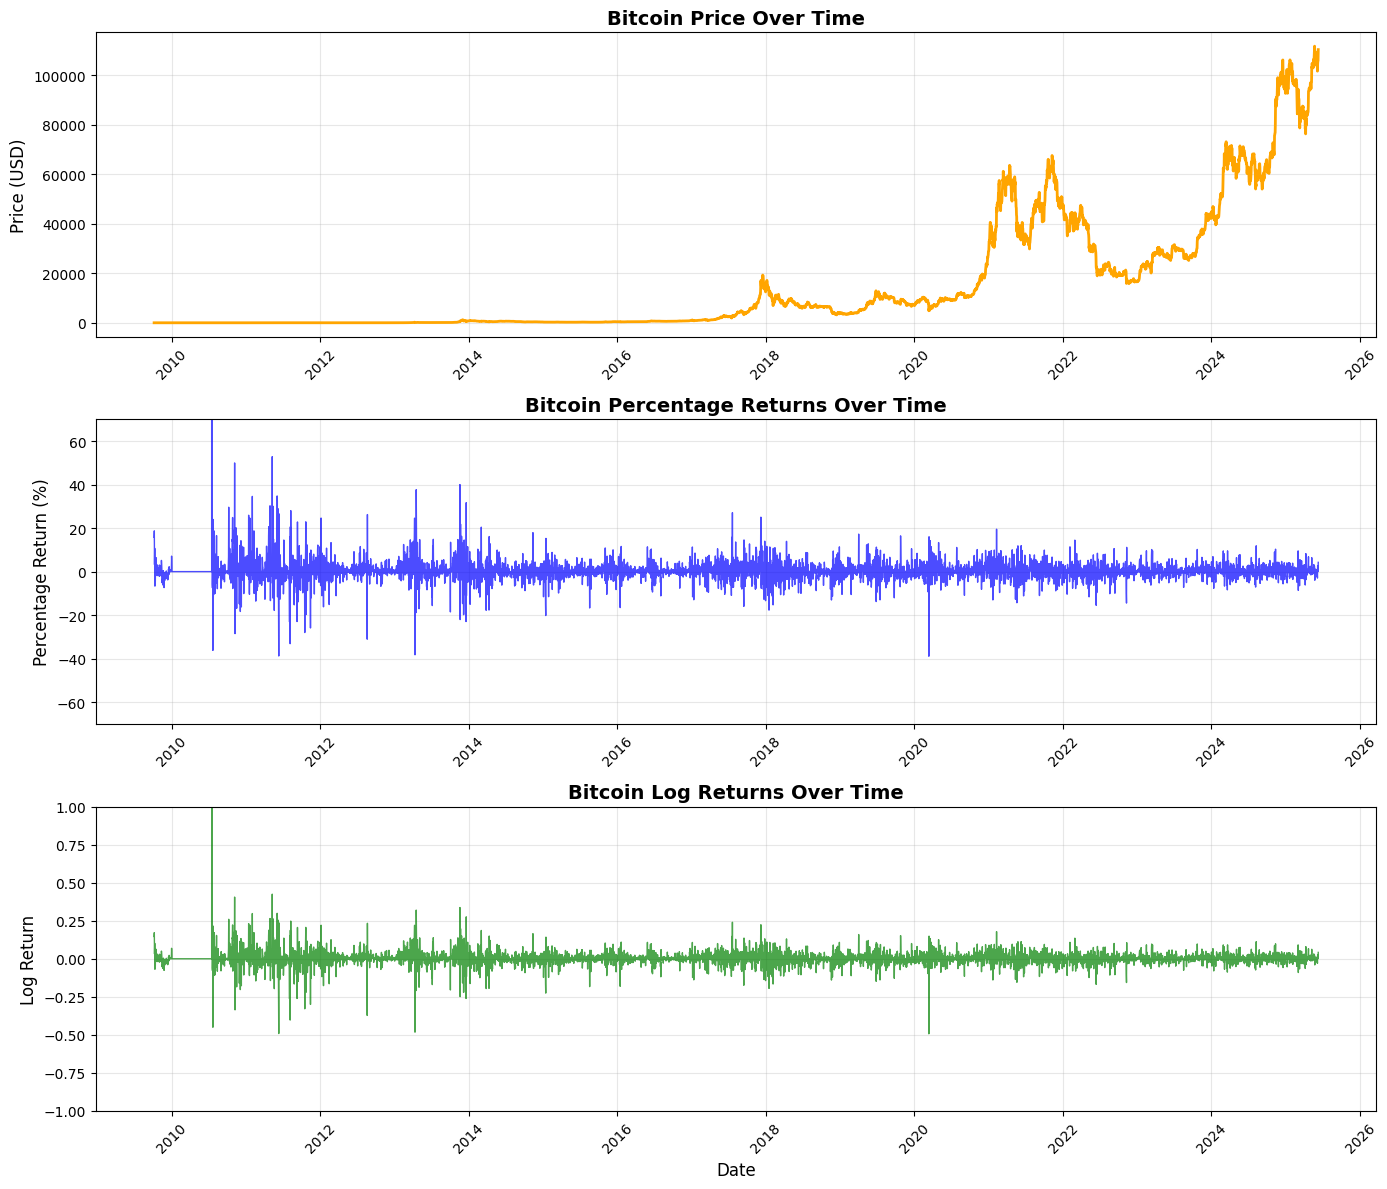

Bitcoin Data Summary Statistics:
Price Range: $0.00 - $111,699.80
Average Daily Return: 1.5580%
Return Volatility (std): 89.9045%
Max Daily Gain: 6793.43%
Max Daily Loss: -38.93%


In [22]:
# Create visualizations for Bitcoin data
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Bitcoin Price Over Time
axes[0].plot(bitcoin['Datetime'], bitcoin['Close'], color='orange', linewidth=2)
axes[0].set_title('Bitcoin Price Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Percentage Returns Over Time
axes[1].plot(bitcoin['Datetime'], bitcoin['Pct Return'] * 100, color='blue', linewidth=1, alpha=0.7)
axes[1].set_title('Bitcoin Percentage Returns Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percentage Return (%)', fontsize=12)
axes[1].set_ylim(-70, 70)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Log Returns Over Time
axes[2].plot(bitcoin['Datetime'], bitcoin['Log Return'], color='green', linewidth=1, alpha=0.7)
axes[2].set_title('Bitcoin Log Returns Over Time', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Log Return', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylim(-1, 1)  # Set y-axis limits from -1 to 1
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print some summary statistics
print("Bitcoin Data Summary Statistics:")
print("="*50)
print(f"Price Range: ${bitcoin['Close'].min():,.2f} - ${bitcoin['Close'].max():,.2f}")
print(f"Average Daily Return: {bitcoin['Pct Return'].mean()*100:.4f}%")
print(f"Return Volatility (std): {bitcoin['Pct Return'].std()*100:.4f}%")
print(f"Max Daily Gain: {bitcoin['Pct Return'].max()*100:.2f}%")
print(f"Max Daily Loss: {bitcoin['Pct Return'].min()*100:.2f}%")


In [23]:
df = exchange_holdings.merge(miner_reserves, on='Datetime', how='inner')
df = df.merge(puell_multiple, on='Datetime', how='inner')
df = df.merge(hashrate, on='Datetime', how='inner')
df = df.merge(mean_coin_age, on='Datetime', how='inner')
df = df.merge(funding_rate, on='Datetime', how='inner')
df = df.merge(open_interest, on='Datetime', how='inner')
df = df.merge(fee_reward_ratio, on='Datetime', how='inner')
df = df.merge(active_addresses, on='Datetime', how='inner')
df = df.merge(exchange_netflow, on='Datetime', how='inner')
df = df.merge(sopr, on='Datetime', how='inner')
df = df.merge(mvrv_ratio, on='Datetime', how='inner')
df = df.merge(bitcoin[["Datetime", "Close","Pct Return Target", "Log Return Target", "Direction"]], on='Datetime', how='inner')

df['Datetime'] = df['Datetime'].dt.tz_localize(None)
cutoff = pd.to_datetime('2018-01-01')                            # training period
df = df[df['Datetime'] >= cutoff].reset_index(drop=True)

print(df.head())
print(df.tail())

    Datetime  Exchange Reserve  Miner Reserve  Puell Multiple      Hashrate  \
0 2025-06-09      2.502490e+06   1.808101e+06        1.243001  8.837253e+11   
1 2025-06-08      2.505618e+06   1.807721e+06        1.337595  9.657855e+11   
2 2025-06-07      2.505247e+06   1.807631e+06        1.245541  9.026623e+11   
3 2025-06-06      2.507173e+06   1.807638e+06        1.152875  8.458514e+11   
4 2025-06-05      2.513402e+06   1.807730e+06        1.156797  8.458514e+11   

   Mean Coin Age  Funding Rates  Open Interest  Fee-Reward Ratio  \
0    1617.120227       0.002927   3.784251e+10          0.011309   
1    1616.485453       0.002124   3.604954e+10          0.006581   
2    1615.764529      -0.000949   3.601397e+10          0.007294   
3    1615.110946      -0.004703   3.543465e+10          0.010475   
4    1614.501350       0.001402   3.385101e+10          0.011510   

   Active Addresses  Exchange Netflow      SOPR  MVRV Ratio          Close  \
0            893460      -3127.633553 

--------------------- CORRELATION MATRIX AND ANALYSIS ---------------------

Correlation Matrix:
                  Exchange Reserve  Miner Reserve  Puell Multiple  Hashrate  \
Exchange Reserve             1.000          0.112          -0.128    -0.298   
Miner Reserve                0.112          1.000          -0.240    -0.745   
Puell Multiple              -0.128         -0.240           1.000    -0.052   
Hashrate                    -0.298         -0.745          -0.052     1.000   
Mean Coin Age               -0.023         -0.637          -0.161     0.905   
Funding Rates               -0.088         -0.161           0.586    -0.012   
Open Interest               -0.239         -0.809          -0.010     0.868   
Fee-Reward Ratio            -0.040          0.002           0.389    -0.044   
Active Addresses             0.026         -0.295           0.399     0.326   
Exchange Netflow             0.071          0.043           0.100    -0.079   
SOPR                        -0.215         -0.264           0.392     0.248   
MVRV Ratio                  -0.1

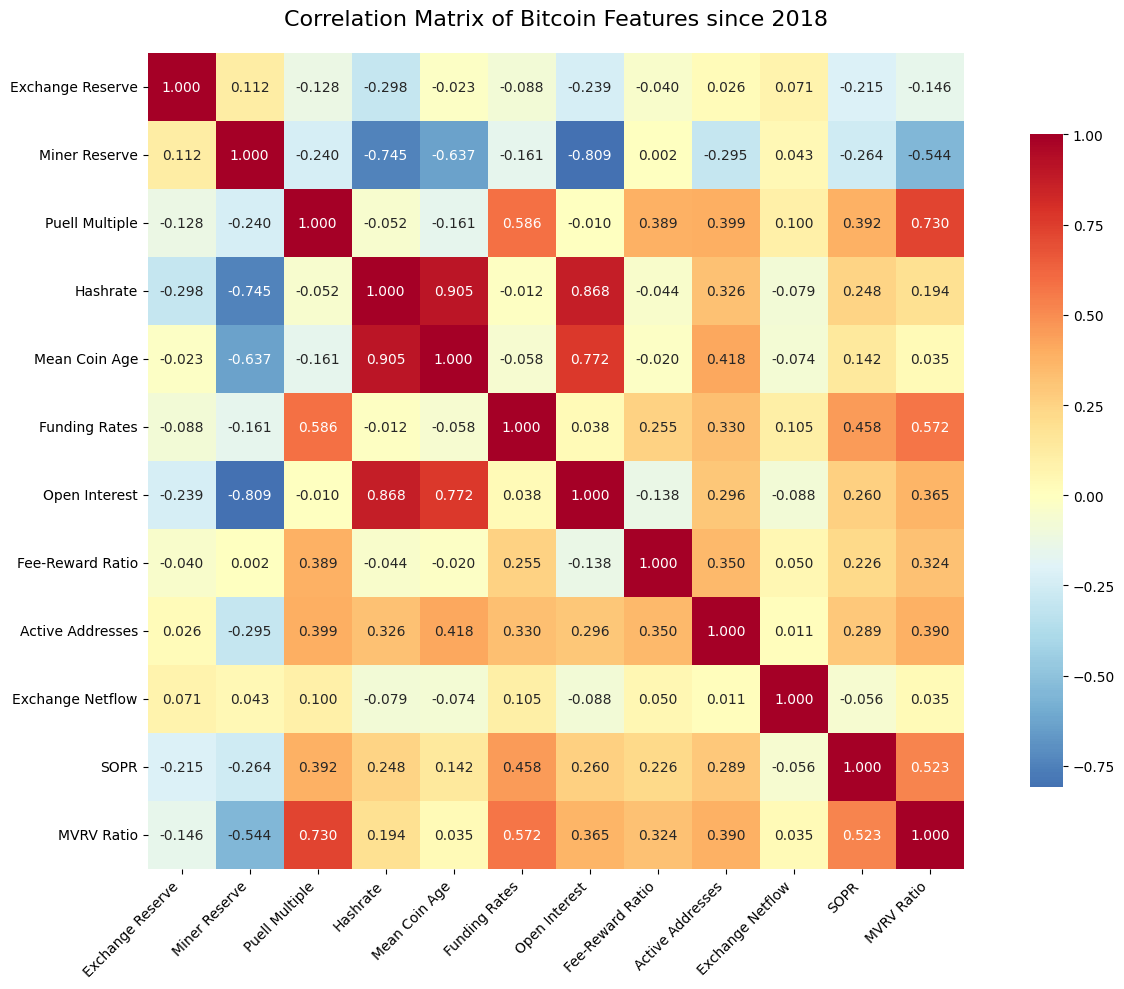


Highly Correlated Feature Pairs (|correlation| > 0.7):
Miner Reserve - Hashrate: -0.745
Miner Reserve - Open Interest: -0.809
Puell Multiple - MVRV Ratio: 0.730
Hashrate - Mean Coin Age: 0.905
Hashrate - Open Interest: 0.868
Mean Coin Age - Open Interest: 0.772

Correlation with Log Return Target:
Exchange Reserve   -0.058
Open Interest      -0.032
Funding Rates      -0.017
Active Addresses    0.014
Exchange Netflow    0.012
MVRV Ratio         -0.008
Miner Reserve       0.007
Fee-Reward Ratio    0.007
Mean Coin Age      -0.006
Puell Multiple      0.005
Hashrate            0.002
SOPR                0.000
Name: Log Return Target, dtype: float64


In [24]:
feature_cols = ["Exchange Reserve", "Miner Reserve", "Puell Multiple", "Hashrate", 
               "Mean Coin Age", "Funding Rates", "Open Interest", "Fee-Reward Ratio", 
               "Active Addresses", "Exchange Netflow", "SOPR", "MVRV Ratio"]

correlation_matrix = df[feature_cols].corr()
print("Correlation Matrix:")
print(correlation_matrix.round(3))

# HEATMAP!
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdYlBu_r', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Bitcoin Features since 2018', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((correlation_matrix.columns[i], 
                                  correlation_matrix.columns[j], 
                                  corr_val))

if high_corr_pairs:
    for feature1, feature2, corr in high_corr_pairs:
        print(f"{feature1} - {feature2}: {corr:.3f}")
else:
    print("No feature pairs with correlation > 0.7 found.")

# Correlation with target variable
target_corr = df[feature_cols + ["Log Return Target"]].corr()["Log Return Target"].drop("Log Return Target")
print(f"\nCorrelation with Log Return Target:")
print(target_corr.sort_values(key=abs, ascending=False).round(3))


-------------------- REGRESSION / MODEL CONSTRUCTION --------------------

Now, we will construct our factor model. First, we have to split the data into a training set and a testing set. Then, we will fit the linear regression model and evaluate its performance. The cutoff date and split date are set to be easily changeable.

In [25]:
split_date = pd.to_datetime('2025-01-01')

X = df[["Exchange Reserve", "Miner Reserve", "Puell Multiple", "Hashrate", "Fee-Reward Ratio", "SOPR",
        "Active Addresses", "Exchange Netflow", "Funding Rates", "Mean Coin Age", "MVRV Ratio", "Open Interest"]]
y = df[["Log Return Target"]]

# split data
X_train = X[df["Datetime"] < split_date]
X_test = X[df["Datetime"] >= split_date]
y_train = y[df["Datetime"] < split_date]
y_test = y[df["Datetime"] >= split_date]


Let's use a random forest (of decision trees) to try and evaluate which factors are most important within our regression models. The Random Forest Regressor is used to predict Log Returns, and at each node, it attempts to choose the best feature / threshold to minimize MSE.

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
Tuned R² Score: -0.454474158433571


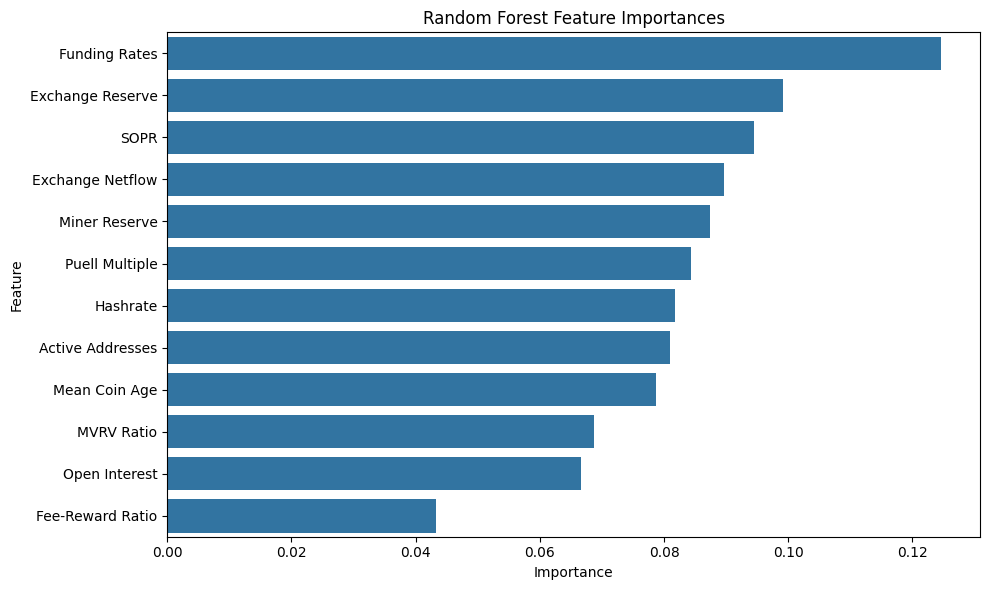

In [26]:
param_grid = {
    'n_estimators': [100, 300, 500],  # number of decision trees
    'max_depth': [5, 10, 20, None],   # maximum depth of each decision tree
    'min_samples_split': [2, 5],      # minimum samples required to split an internal node
    'max_features': ['sqrt', 'log2']  # best split criteria
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0)
# Fix the y_train shape issue to prevent DataConversionWarning
y_train_flat = y_train.values.ravel()
grid.fit(X_train, y_train_flat)

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
print("Best Parameters:", grid.best_params_)
print("Tuned R² Score:", r2_score(y_test, y_pred))

importances = best_rf.feature_importances_
features = X.columns
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

In [27]:
# Linear Regression
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())


# Ridge Regression (should ideally address multicollinearity, reduce overfitting)
pipeline = make_pipeline(StandardScaler(), Ridge())
param_grid = {'ridge__alpha': np.logspace(-4, 4, 20)}
tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(estimator=pipeline,
                    param_grid=param_grid,
                    cv=tscv,
                    scoring='r2',
                    n_jobs=-1,
                    verbose=1)
grid.fit(X_train, y_train)

print("--------------------------------")
print("Best Parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

best_model = grid.best_estimator_
r2_test = best_model.score(X_test, y_test)
print("Test Set R²:", r2_test)


                            OLS Regression Results                            
Dep. Variable:      Log Return Target   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.252
Date:                Mon, 23 Jun 2025   Prob (F-statistic):            0.00794
Time:                        11:40:03   Log-Likelihood:                 4057.4
No. Observations:                2104   AIC:                            -8089.
Df Residuals:                    2091   BIC:                            -8015.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3253      0.172  

Linear / ridge regression, especially with these factors, seem entirely unhelpful / unrelated.